---
title: Block maxima
subtitle: Reducing daily records to extremes at different time scales
short_title: Block maxima
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - block maxima
  - extremes
  - time scales
  - Iberia
abstract: |
  The block-maxima method reduces a long record to the maximum of each block —
  the hottest day per week, month, season or year. This notebook is a hands-on
  look at that operation on real Iberian station data: we extract maxima at
  several block lengths with `xtremax`, compare the resulting series and
  histograms, and see how block length trades the *number* of maxima against how
  *extreme* and how *regular* they are. No distribution is fitted yet — that
  comes next; here we just build intuition for the data.
---

# From daily series to block maxima

A station gives us thousands of daily values, but we care about the **rare hot
extremes**. The block-maxima method is the first, simplest reduction: split the
record into equal blocks and keep only the maximum of each. This notebook
explores that operation — purely as data — at several block lengths.

## Background

For a block of daily maxima $X_1, X_2, \dots, X_n$, the **block maximum** is just

```{math}
:label: eq:block-max
M \;=\; \max\{X_1, X_2, \dots, X_n\}.
```

The only real choice is the **block length**. A short block (a week) yields many
maxima, each only mildly extreme; a long block (a year) yields few maxima, each
genuinely rare. The block length also controls how *identically distributed* the
maxima are — short blocks straddle the seasonal cycle, long ones absorb it. We
make both effects concrete below, using
[`xtremax.extraction.temporal_block_maxima`](https://github.com/jejjohnson/xtremax).

## Setup

In [1]:
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while not (_p / "src" / "spatial_extremes").exists():
    if _p == _p.parent:
        raise RuntimeError("Run from inside the spatial_extremes project")
    _p = _p.parent
if str(_p / "src") not in sys.path:
    sys.path.insert(0, str(_p / "src"))

In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

from spatial_extremes import data
from spatial_extremes.places import country_from_id, station_label
from spatial_extremes.viz import iberia_axes, scatter_field, mark_points, mark_star
from xtremax.extraction import temporal_block_maxima

df, is_real = data.load_station_daily()
da = data.to_station_time_dataarray(df)        # daily-max cube, dims (station, time)
yr = da["time"].dt.year.values
print("source:", "REAL CDS" if is_real else "synthetic fallback")
print(f"daily cube: {dict(da.sizes)}  |  {yr.min()}–{yr.max()}")

source: REAL CDS
daily cube: {'station': 185, 'time': 14986}  |  1985–2026


## The station network

Before reducing anything, a quick look at coverage: real networks are ragged, so
we note how many stations carry long, complete records. The map colours each
station by the number of years for which it has a usable annual maximum.

In [3]:
annual = temporal_block_maxima(da, freq="YE", time_dim="time", min_periods=300)
annual = annual.dropna("time", how="all")
n_station, n_year = annual.sizes["station"], annual.sizes["time"]
valid_years = annual.notnull().sum("time")
print(f"annual-maxima cube: {n_station} stations × {n_year} years")
for k in (26, 20, 15, 10):
    print(f"  stations with >= {k:>2} valid years: {int((valid_years >= k).sum())}")

annual-maxima cube: 185 stations × 41 years
  stations with >= 26 valid years: 89
  stations with >= 20 valid years: 89
  stations with >= 15 valid years: 150
  stations with >= 10 valid years: 168


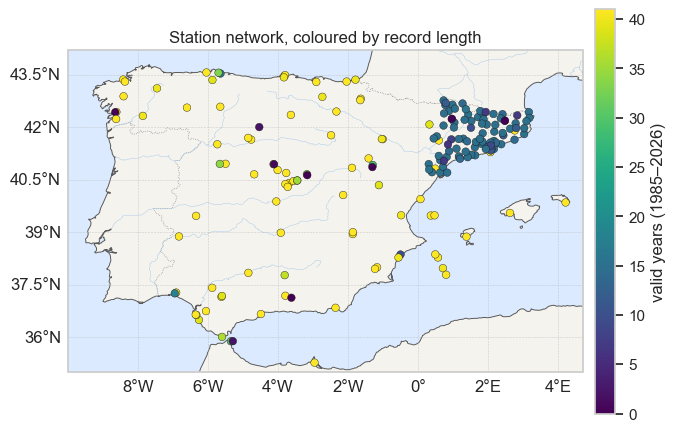

In [4]:
ax = iberia_axes(figsize=(8, 7))
scatter_field(ax, annual["lon"].values, annual["lat"].values, valid_years.values,
              label=f"valid years ({yr.min()}–{yr.max()})", cmap="viridis", s=30)
ax.set_title("Station network, coloured by record length")
plt.show()

## Block maxima at four time scales

We pick the best-covered (and warmest) station as a running example and extract
its maxima at four block lengths: **weekly, monthly, seasonal (3-month) and
annual**. The number of maxima shrinks by roughly the block length, while each
maximum becomes more extreme.

In [5]:
order = valid_years + annual.mean("time") / 1e3       # coverage, tie-break warm
sidx = int(np.asarray(order.values).argmax())
sid = str(annual["station"].values[sidx])
lon, lat = float(da["lon"][sidx]), float(da["lat"][sidx])
label = station_label(sid, lon, lat)

SCALES = [("weekly", "W"), ("monthly", "ME"), ("seasonal", "QE"), ("annual", "YE")]
series = da.isel(station=sidx)
maxima = {name: temporal_block_maxima(series, freq=f, time_dim="time").dropna("time")
          for name, f in SCALES}
print("showcase station:", label)
for name, _ in SCALES:
    m = maxima[name]
    print(f"  {name:>9}: {m.sizes['time']:>5} maxima   "
          f"mean {float(m.mean()):.1f} °C   max {float(m.max()):.1f} °C")

showcase station: SPE00120116 · near Madrid, Spain
     weekly:    40 maxima   mean 25.7 °C   max 38.4 °C
    monthly:     9 maxima   mean 28.5 °C   max 38.4 °C
   seasonal:     3 maxima   mean 31.1 °C   max 38.4 °C
     annual:     1 maxima   mean 38.4 °C   max 38.4 °C


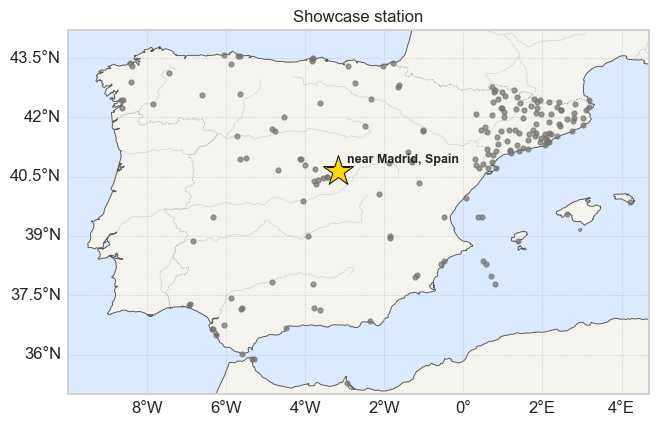

In [6]:
# locator map with a star
ax = iberia_axes(figsize=(7.5, 6.5))
mark_points(ax, annual["lon"].values, annual["lat"].values, s=12,
            color="0.45", alpha=0.7)
mark_star(ax, lon, lat, label=label.split(" · ")[1], size=520)
ax.set_title("Showcase station")
plt.show()

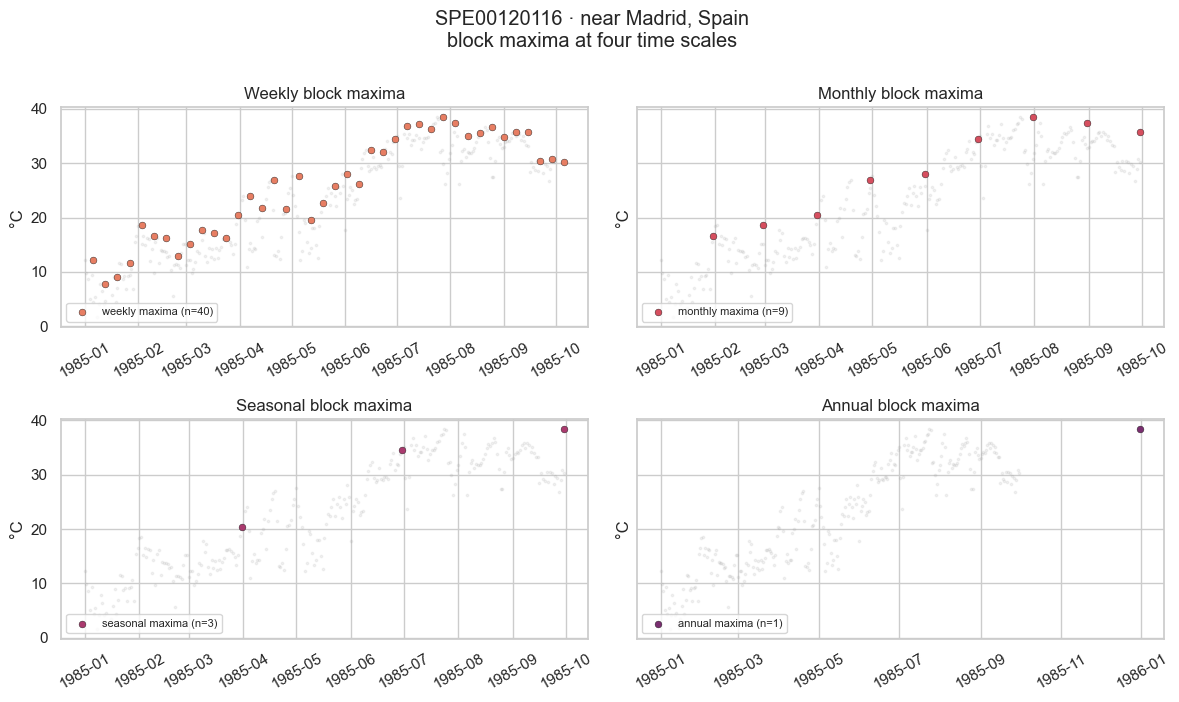

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
colors = sns.color_palette("flare", 4)
for ax, (name, _), c in zip(axes.ravel(), SCALES, colors):
    ax.scatter(series["time"].values, series.values, s=3, alpha=0.12, color="0.6")
    m = maxima[name]
    ax.scatter(m["time"].values, m.values, s=24, color=c, edgecolor="k",
               linewidth=0.3, label=f"{name} maxima (n={m.sizes['time']})")
    ax.set_title(f"{name.capitalize()} block maxima")
    ax.legend(loc="lower left", fontsize=8)
    ax.set_ylabel("°C")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle(f"{label}\nblock maxima at four time scales", y=1.0)
fig.tight_layout()
plt.show()

## How block length shapes the distribution

Pooling the maxima across *all* stations, the histograms show the trade-off
directly: short blocks pile up near the seasonal warm-season temperatures, while
longer blocks push the mass right and thin the upper tail into a smooth,
right-skewed shape. The dashed line marks each scale's median.

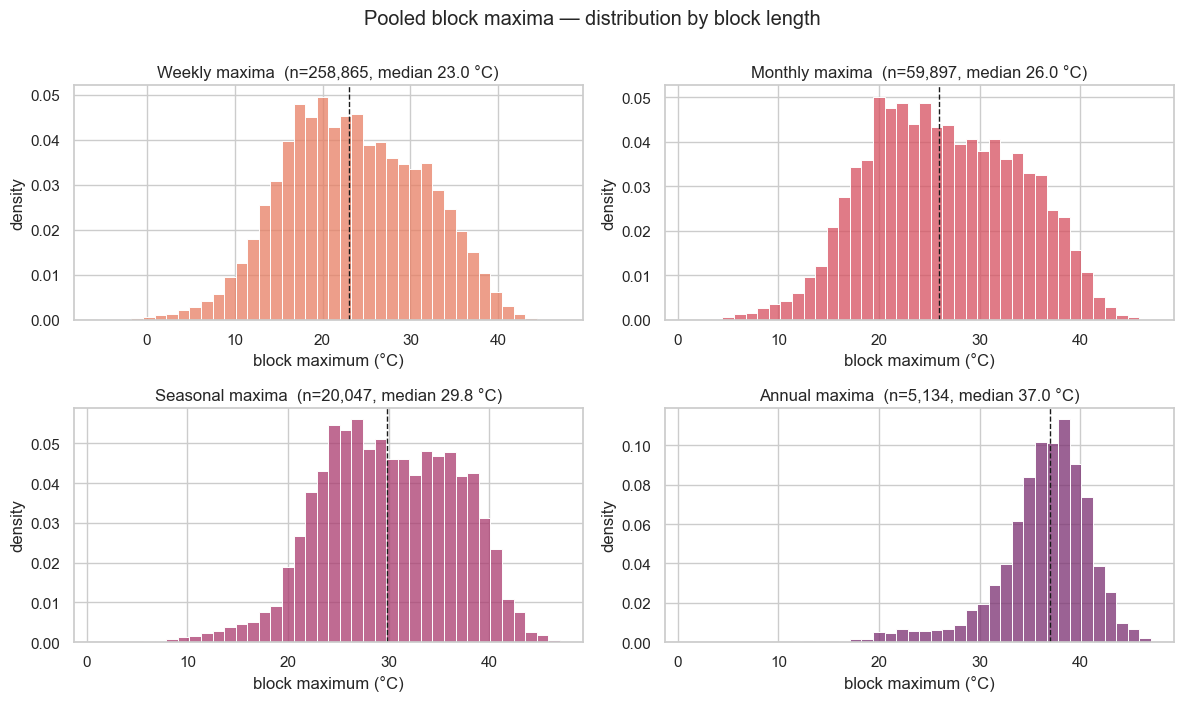

In [8]:
def pooled(freq):
    m = temporal_block_maxima(da, freq=freq, time_dim="time")
    v = m.values[np.isfinite(m.values)]
    return v

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
colors = sns.color_palette("flare", 4)
for ax, (name, freq), c in zip(axes.ravel(), SCALES, colors):
    v = pooled(freq)
    sns.histplot(v, bins=40, stat="density", color=c, ax=ax, edgecolor=None)
    ax.axvline(np.median(v), color="k", ls="--", lw=1)
    ax.set(title=f"{name.capitalize()} maxima  (n={v.size:,}, median {np.median(v):.1f} °C)",
           xlabel="block maximum (°C)", ylabel="density")
fig.suptitle("Pooled block maxima — distribution by block length", y=1.0)
fig.tight_layout()
plt.show()

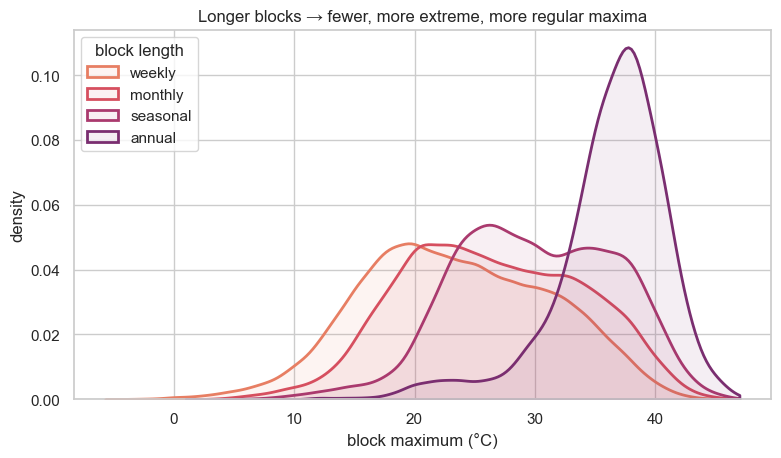

In [9]:
# the same four, overlaid as densities, to see the rightward march
fig, ax = plt.subplots(figsize=(9, 4.8))
for (name, freq), c in zip(SCALES, sns.color_palette("flare", 4)):
    sns.kdeplot(pooled(freq), ax=ax, label=name, color=c, lw=2, fill=True,
                alpha=0.08, cut=0)
ax.set(xlabel="block maximum (°C)", ylabel="density",
       title="Longer blocks → fewer, more extreme, more regular maxima")
ax.legend(title="block length")
plt.show()

## Why annual blocks for extremes?

There is a second reason to prefer long blocks. A block maximum is only a clean,
comparable quantity if every block is drawn from the *same* conditions. Monthly
maxima are not: a July maximum and a January maximum come from completely
different seasonal regimes. An **annual** block folds a whole seasonal cycle into
each maximum, so all the $M$ in {eq}`eq:block-max` are comparable. The boxplot of
this station's monthly maxima makes the seasonal dependence obvious.

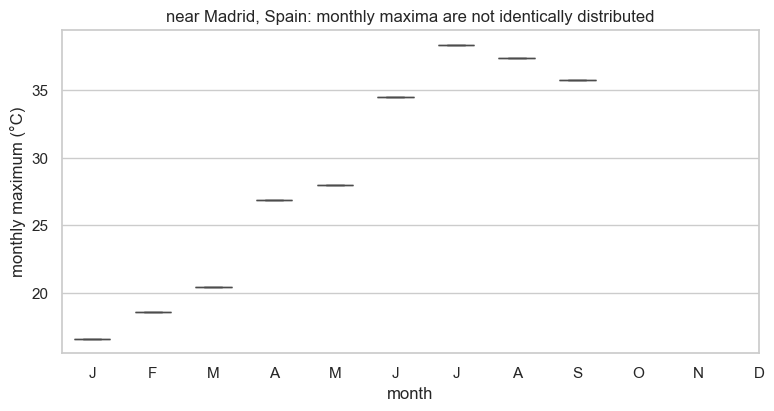

In [10]:
mm = temporal_block_maxima(series, freq="ME", time_dim="time")
mdf = mm.to_dataframe(name="tmax").dropna().reset_index()
mdf["month"] = mdf["time"].dt.month
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.boxplot(data=mdf, x="month", y="tmax", ax=ax, color="#4C72B0", width=0.6)
ax.set_xticks(range(12), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set(xlabel="month", ylabel="monthly maximum (°C)",
       title=f"{label.split(' · ')[1]}: monthly maxima are not identically distributed")
plt.show()

## Recap & where next

Block maxima reduce a daily record to a handful of extremes, and the block
length sets the bargain: shorter blocks give more but milder and seasonally
mixed maxima; **annual** blocks give few, genuinely rare, mutually comparable
maxima. From here on we work with annual maxima. In
[](02_gev_one_station.ipynb) we ask what *distribution* those annual maxima
follow, and fit it to a single station.